In [57]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import re 

import pickle

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs, PROPERTY_NAMES

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
# Generate output folder
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis")
output_folder.mkdir(exist_ok=True)

In [59]:
datasets_to_plot = [# 'hcp_schaefer_100_dataset_gnm', 
                        # 'hcp_schaefer_100_dataset', 
                        # 'suarez_MaMI_dataset', 
                        
                        # 'lexis_data_young', 
                        # 'lexis_data_aging',
                        # 'lexis_data_developing', 
                        
                        # 'kaysons_generated_networks_diffusion', 
                        # 'kaysons_generated_networks_propagation', 
                        # 'kaysons_generated_networks_routing', 
                        # 'kaysons_generated_networks_topology',
                        
                        "lexis_data_developing_consensus_per_age_1_year",
                        # "lexis_data_young_consensus_per_age_1_year",
                        # "lexis_data_aging_consensus_per_age_1_year",
                        # "lexis_data_all_consensus_per_age_1_year",
                        # "lexis_data_all_consensus_per_age_2_year",
                        # "lexis_data_developing_consensus_per_age_2_year",
                        ]

In [60]:
dict_with_all_datasets = {}


columns_to_remove = ["distance_relationship_type", "generative_rule", "num_iterations", "preferential_relationship_type", 
                         "id", "network_idx", "network_index", 
                         "mc_values_for_indiv_lags"]


for dataset_name in datasets_to_plot:
    
    if dataset_name == "hcp_schaefer_100_dataset_gnm":
        continue  # We already processed the gnm data for this dataset, so we skip it here.
    
    # Do the same thing for the empirical data.
    experiment_name_emp = emp_dataset_and_experiment_pairs[dataset_name]
    base_path_emp = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name_emp}")
    precise_emp_files = {"static": f"metrics_2_static.csv", 
                         "dynamic": f"metrics_2_dynamic.csv",
                         "computational": f"metrics_2_computational.csv",
                         "further": f"metrics_2_further.csv"}
    
    # Combine them all to one big dataframe. The indeces correspond to same entries across the different metric types, so we can easily merge them. Check first if the dfs are equally long. 
    dfs = {key: pd.read_csv(base_path_emp / file) for key, file in precise_emp_files.items()}
    lengths = {key: len(df) for key, df in dfs.items()}
    print(lengths)
    # They are all equally long, so we can merge them on the index.
    # df = pd.concat(dfs.values(), axis=1)
    df = dfs["static"]  # Start with the static df as the base
    for key in precise_emp_files.keys():
        if key == "static":
            continue  # Skip the static df since it's already our base
        print(key)
        df = df.merge(dfs[key], left_index=True, right_index=True, how="left", suffixes=("", f"_{key}"))
    
        
    # Rename columns: strip "basic_measures_" prefix where present
    df.columns = [col.replace("basic_measures_", "") if col.startswith("basic_measures_") else col for col in df.columns]
    
    # Rename columns: strip "mc_original_" prefix where present
    df.columns = [col.replace("mc_original_", "") if col.startswith("mc_original_") else col for col in df.columns]

    # Check if there are duplicate columns after merging. If so, we can drop them - but print them first to see which ones they are.
    duplicate_columns_emp = df.columns[df.columns.duplicated()]
    print("Attention: Duplicate entries (did not get removed so far):", duplicate_columns_emp)
    # Remove exact-duplicate columns (content-identical), keep first occurrence
    cols_to_keep = []
    seen = {}
    for i, col in enumerate(df.columns):
        if col not in seen:
            seen[col] = i
            cols_to_keep.append(i)
        else:
            # Check if the duplicate column is identical in content
            if df.iloc[:, seen[col]].equals(df.iloc[:, i]):
                print(f"  -> Dropping identical duplicate column: '{col}'")
            else:
                # Keep both but rename the duplicate
                new_name = f"{col}_dup"
                df.columns.values[i] = new_name
                cols_to_keep.append(i)
                print(f"  -> Kept non-identical duplicate column '{col}' as '{new_name}'")
    df = df.iloc[:, cols_to_keep]
    
    # drop "repertoire_sweep_T_vec", "repertoire_sweep_sizes", "repertoire_sweep_diversities", if those columns are present in the df, since they are not relevant for the analysis and they have many missing values.
    for col in ["repertoire_sweep_T_vec", "repertoire_sweep_sizes", "repertoire_sweep_diversities", 
                "repertoire_sweep_weighted_by_distances_T_vec", "repertoire_sweep_weighted_by_distances_sizes", "repertoire_sweep_weighted_by_distances_diversities", 
                "repertoire_sweep_T_critical", "repertoire_sweep_size_critical", "repertoire_sweep_diversity_critical", 
                "proportion_long_range_connections_0.356", 
                "repertoire_diversity", "repertoire_size", 
                "departure_from_normality" # As this one has nones now??? TODO. 
                ]:
        if col in df.columns:
            df = df.drop(col, axis=1)
            print(f"Dropped column '{col}' from '{dataset_name}' because it had many missing values and is not relevant for the analysis.")
        else:
            print(f"Column '{col}' not found in '{dataset_name}', so it was not dropped.")

            
    # Remove columns if all their entries are empty 
    df = df.dropna(axis=1, how="all")

    # if there is n_components in the df, then exclude the rows where n_components != 1 and print the row ids 
    if "n_connected_components" in df.keys():          
        # Get all rows where n_connected_components != 1; print them and exclude them
        non_singleton_components = df[df['n_connected_components'] != 1]
        indices_to_remove = non_singleton_components.index.tolist()
        if len(indices_to_remove) > 0: 
            print("⚠️ Non-singleton components. IDs that are going to be removed: ", indices_to_remove) #  "their 'network_id' or similar values:", non_singleton_components[["id", "network_index", "network_idx"]]))
            # df = df[df['n_connected_components'] == 1]
            df = df[~df.index.isin(indices_to_remove)]
            print(" ---> Done. New df length:", len(df))
        
    # Remove unimportant columns
    columns_to_remove += [col for col in df.columns if col.startswith("h_params")]
    df = df.drop(columns=[col for col in columns_to_remove if col in df.columns])


    # Check the shape of the final df   
    print(df.shape)
    dict_with_all_datasets[dataset_name] = df
    

# SAVE THE DICT 
with open(output_folder / "all_datasets.pkl", "wb") as f:
    pickle.dump(dict_with_all_datasets, f)


{'static': 17, 'dynamic': 17, 'computational': 17, 'further': 17}
dynamic
computational
further
Attention: Duplicate entries (did not get removed so far): Index(['global_efficiency', 'modularity', 'avg_clustering', 'avg_degree',
       'transitivity', 'wiring_cost'],
      dtype='object')
  -> Dropping identical duplicate column: 'global_efficiency'
  -> Kept non-identical duplicate column 'modularity' as 'modularity_dup'
  -> Dropping identical duplicate column: 'avg_clustering'
  -> Dropping identical duplicate column: 'avg_degree'
  -> Dropping identical duplicate column: 'transitivity'
  -> Kept non-identical duplicate column 'wiring_cost' as 'wiring_cost_dup'
Column 'repertoire_sweep_T_vec' not found in 'lexis_data_developing_consensus_per_age_1_year', so it was not dropped.
Column 'repertoire_sweep_sizes' not found in 'lexis_data_developing_consensus_per_age_1_year', so it was not dropped.
Column 'repertoire_sweep_diversities' not found in 'lexis_data_developing_consensus_per_age

lexis_data_developing_consensus_per_age_1_year
done


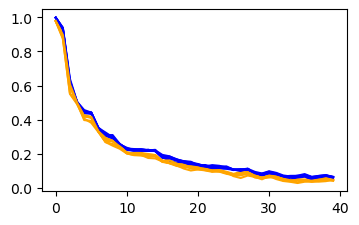

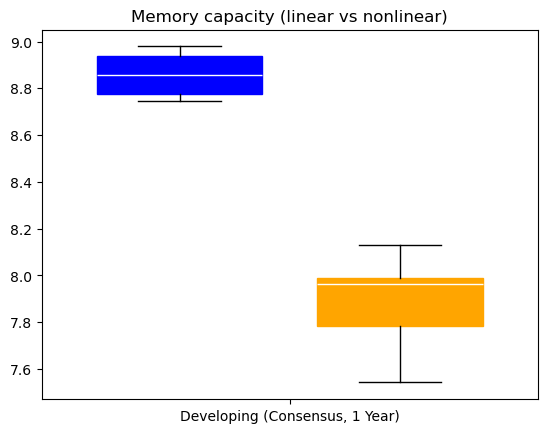

In [61]:
mc_per_dataset = {}

lin ="mc_input_scaling_0_1_mc_values_for_indiv_lags"
non_lin = "mc_nonlinear_input_scaling_0_1_mc_values_for_indiv_lags"
    

for dataset in datasets_to_plot:
    plt.figure(figsize=viz.cm_to_inch((10, 6)))
    
    print(dataset)  
    mc_lin_arr = []
    mc_nonlin_arr = []
    
    # iterate trough all rows 
    for idx, row in dict_with_all_datasets[dataset].iterrows():

        lin_profile = row[lin]
        nonlin_profile = row[non_lin]

        lin_profile = lin_profile.strip("[]").split(",")
        lin_profile = np.array(lin_profile).astype(np.float32)

        nonlin_profile = nonlin_profile.strip("[]").split(",")
        nonlin_profile = np.array(nonlin_profile).astype(np.float32)

        plt.plot(lin_profile, label="lin", color="blue")
        plt.plot(nonlin_profile, label="nonlin", color="orange")
        
        mc_lin_arr.append(lin_profile.sum())
        mc_nonlin_arr.append(nonlin_profile.sum())

        if idx % 10 == 5:
            print("done")
            break

    mc_per_dataset[dataset] = {
        "lin": mc_lin_arr,
        "nonlin": mc_nonlin_arr
    }

    plt.show() 


plt.boxplot([mc_per_dataset[dataset]["lin"] for dataset in datasets_to_plot], 
            positions=np.array(range(len(datasets_to_plot)))*2.0-0.4, 
            widths=0.6, 
            patch_artist=True, 
            boxprops=dict(facecolor="blue", color="blue"),
            medianprops=dict(color="white"))
plt.title("Memory capacity (linear vs nonlinear)")

plt.boxplot([mc_per_dataset[dataset]["nonlin"] for dataset in datasets_to_plot], 
            positions=np.array(range(len(datasets_to_plot)))*2.0+0.4, 
            widths=0.6, 
            patch_artist=True, 
            boxprops=dict(facecolor="orange", color="orange"),
            medianprops=dict(color="white"))

plt.xticks(np.array(range(len(datasets_to_plot)))*2.0, [LABEL_MAP[dataset] for dataset in datasets_to_plot], 
        #    rotation=45, 
        #    ha="right"
        )
plt.show() 
    
# plt.tight_layout()


In [62]:
# Quick overview of what's in each dataset 
print("\n" + "=" * 60)
print("Datasets loaded:")
for name in dict_with_all_datasets:
    print(f"  {name}: {dict_with_all_datasets[name].shape}")


Datasets loaded:
  lexis_data_developing_consensus_per_age_1_year: (17, 363)


In [63]:
# Make a nice comparison table: which properties each dataset has
# Collect all unique column names across datasets
all_columns = set()
for df in dict_with_all_datasets.values():
    all_columns.update(df.columns)
all_columns = sorted(all_columns)

# Build a presence table
presence_table = pd.DataFrame(index=all_columns, columns=list(dict_with_all_datasets.keys()))
for dataset_name, df in dict_with_all_datasets.items():
    for col in all_columns:
        presence_table.loc[col, dataset_name] = "y" if col in df.columns else "missing"

presence_table.rename(columns=LABEL_MAP, inplace=True)

print("\n" + "=" * 60)
print("Property presence table:")
print(presence_table.to_string())

# Save the table to CSV
presence_table.to_csv(output_folder / "property_presence_table.csv")
print(output_folder / "property_presence_table.csv")
print("\nSaved property presence table.")


Property presence table:
                                                                              Developing (Consensus, 1 Year)
algebraic_connectivity_fiedler_bipartition_balance                                                         y
algebraic_connectivity_fiedler_value                                                                       y
algebraic_connectivity_fiedler_value_norm                                                                  y
algebraic_connectivity_laplacian_spectral_gap                                                              y
algebraic_connectivity_nx                                                                                  y
avg_clustering                                                                                             y
avg_communicability                                                                                        y
avg_degree                                                                                            

In [65]:
import json

# Generate a template dict mapping each column name to an empty display name
property_names_template = {col: "" for col in all_columns}

# Print as a Python dict literal ready to copy-paste and fill in
print("\nPROPERTY_NAMES = {")
for col in all_columns:
    print(f'    "{col}": "",')
print("}")


PROPERTY_NAMES = {
    "algebraic_connectivity_fiedler_bipartition_balance": "",
    "algebraic_connectivity_fiedler_value": "",
    "algebraic_connectivity_fiedler_value_norm": "",
    "algebraic_connectivity_laplacian_spectral_gap": "",
    "algebraic_connectivity_nx": "",
    "avg_clustering": "",
    "avg_communicability": "",
    "avg_degree": "",
    "avg_edge_distance": "",
    "char_path_length": "",
    "community_synchronization_vulnerability_n_communities": "",
    "community_synchronization_vulnerability_value": "",
    "computational_capacity_cross_capacity_total": "",
    "computational_capacity_cubic_capacity_total": "",
    "computational_capacity_lyapunov_exponent": "",
    "computational_capacity_memory_capacity_total": "",
    "computational_capacity_memory_nonlinear_ratio": "",
    "computational_capacity_memory_timescale": "",
    "computational_capacity_nonlinear_capacity_total": "",
    "computational_capacity_notebook_damicelli_memory_capacity_profile_notebook"

In [66]:
for dataset in dict_with_all_datasets.keys():
    
    column_names = dict_with_all_datasets[dataset].columns
    # drom the following two columns from the notebook, if they are present: computational_capacity_notebook_memory_capacity_profile_notebook, computational_capacity_notebook_nonlinear_capacity_profile_notebook
    column_names = [col for col in column_names if col not in [
        "computational_capacity_notebook_memory_capacity_profile_notebook",
        "computational_capacity_notebook_nonlinear_capacity_profile_notebook", 
        "computational_capacity_notebook_damicelli_memory_capacity_profile_notebook",
        "computational_capacity_notebook_damicelli_nonlinear_capacity_profile_notebook"
    ]]
    dict_with_all_datasets[dataset] = dict_with_all_datasets[dataset][column_names]
    
    
    # Drop all rows that have nans in them (and print how many rows got dropped)
    before_rows = len(dict_with_all_datasets[dataset])
    # dict_with_all_datasets[dataset] = dict_with_all_datasets[dataset].dropna()
    dict_with_all_datasets[dataset] = dict_with_all_datasets[dataset].dropna(axis=1, how="all")
    after_rows = len(dict_with_all_datasets[dataset])
    print(f"{dataset}: Dropped {before_rows - after_rows} rows with NaN values.") #  Remaining rows: {after_rows}.")

lexis_data_developing_consensus_per_age_1_year: Dropped 0 rows with NaN values.


In [67]:

# Drop all columns that are not of type float or int
for dataset in dict_with_all_datasets.keys():
    columns_to_drop = [col for col in dict_with_all_datasets[dataset].columns if dict_with_all_datasets[dataset][col].dtype not in [np.float64, np.float32, np.int64, np.int32]]
    dict_with_all_datasets[dataset].drop(columns=columns_to_drop, inplace=True)
    print(f"{dataset}: Dropped columns: {columns_to_drop}")

lexis_data_developing_consensus_per_age_1_year: Dropped columns: ['mc_input_scaling_0_1_mc_values_for_indiv_lags', 'mc_nonlinear_input_scaling_0_1_mc_values_for_indiv_lags']


In [68]:

import re
from config import PROPERTY_NAMES

# ── Category definitions ──────────────────────────────────────────────────────
categories = {
    "Fundamental Topology": [ 
        "transitivity", "avg_clustering", "modularity", "degree_gini", # Basic
        "degree_assortativity", "omega", "structural_complexity", 
        
        "directed_simplices_count", # Higher order
        "directed_simplices_max_size",
        
        "energy" # i.e.: Fit to networks - maybe remove again? 
    ],
    "Paths, Efficiency & Communication": [
        "char_path_length", "global_efficiency", "diffusion_efficiency",
        "propagation_efficiency", "avg_communicability",
        "topological_distance_mean", "topological_distance_std",
    ],
    "Spatial Embedding & Wiring Cost": [
        "avg_edge_distance", "wiring_cost",
        "proportion_long_range_connections_0.1",
        "proportion_long_range_connections_0.3",
        "proportion_long_range_connections_0.3956",
        "proportion_long_range_connections_0.5",
    ],
    "Rich-Club Organization": [
        "richclub_n_edges", "richclub_avg_length",
        "rich_club_coefficient_rc_max_norm",
        "rich_club_coefficient_rc_mean_norm",
        "rich_club_coefficient_rc_k_at_max",
        "rich_club_coefficient_rc_regime_frac",
        "rich_club_coefficient_rc_weighted_auc",
    ],
    "Spectral Properties, Algebraic Connectivity & Fiedler Analysis": [
        "spectral_radius", 
        # "synchronizability_eigenratio_lambda_N", # largest eigenvalue. -> spectral radius
        "spectral_gap", # Has exactly the same output as Fatemehs version, bc it is identical (lambda_n - lambda_(n-1))
        # "spectral_gap_fatemeh", 
    # ],
    # "Synchronization & Eigenratio": [
        "synchronizability_eigenratio_eigenratio", # lambda_n / lambda_2
    # ],
        "kernel_rank_thresholded_and_summed_0.01",          # np.sum(np.abs(eigs) > threshold * np.abs(eigs).max())
        # "kernel_rank_max",                                  # biggest eigenvalue
        "kernel_rank_phase_diff_of_lambda_max_and_2nd",     # np.angle(eigs[np.argsort(np.abs(eigs))[-2]]) - np.angle(eigs.max())
                # eigs = np.linalg.eigvals(A)
                #     "thresholded_and_summed_0.01": np.sum(np.abs(eigs) > threshold * np.abs(eigs).max()), 
                #     "max": np.abs(eigs).max(), 
                #     "phase_of_lambda_max": np.angle(eigs.max()), 
                #     "phase_diff_of_lambda_max_and_2nd": np.angle(eigs[np.argsort(np.abs(eigs))[-2]]) - np.angle(eigs.max()), 
                
    # "Algebraic Connectivity & Fiedler Analysis": [
        # "algebraic_connectivity_nx", # Identical to fiedler value....
        "algebraic_connectivity_fiedler_value", # Relies on a different library, I hope? 
        "algebraic_connectivity_fiedler_value_norm",
        # "synchronizability_eigenratio_lambda_2", # Should be fiedler value...  (first non-zero)
        "algebraic_connectivity_laplacian_spectral_gap",
        "algebraic_connectivity_fiedler_bipartition_balance",
        
        "departure_from_normality_schur",
                # """
                # from scipy.linalg import solve_continuous_lyapunov, schur
                # Henrici departure from normality via Schur decomposition.
                
                # For M = QTQ*, the departure equals ||T_off||_F / ||M||_F,
                # where T_off is the strictly upper-triangular part of T.
                
                # This avoids the numerically unstable subtraction
                # ||M||_F^2 - sum|lambda_i|^2 from the eigenvalue-based formula.
                # """
                # A = np.array(A, dtype=np.complex128)

                # norm_F = np.linalg.norm(A, 'fro')
                # if norm_F < 1e-12:
                #     return 0.0
                
                # # Schur decomposition: M = Q T Q^H
                # T, _ = schur(A, output='complex')

                # # Strictly upper-triangular part = non-normal component
                # T_off = np.triu(T, k=1)
                
                # return float(np.linalg.norm(T_off, 'fro') / norm_F)
            
                # ____________________________________________
                # M = np.array(M)
                # # Calculate the Frobenius norm of M
                # norm_F = linalg.norm(M, 'fro')
                # # Compute the eigenvalues of M
                # eigenvalues = np.linalg.eigvals(M)
                # # Compute the sum of the squares of the eigenvalues
                # sum_squares_eigenvalues = np.sum(np.abs(eigenvalues)**2)
                # # Compute the departure from normality
                # d_F = np.sqrt(norm_F**2 - sum_squares_eigenvalues)
                # return d_F/norm_F

        "effective_dimensionality",
                # eigs = np.linalg.eigvals(A)
                # eigs_abs = np.abs(eigs)
                # return np.sum(eigs_abs)**2 / np.sum(eigs_abs**2)
    ],
    # "Kuramoto Synchronization (Single Trial)": [
    #     "kuramoto_synchronization_r_final",
    #     "kuramoto_synchronization_r_mean",
    #     "kuramoto_synchronization_r_std",
    # ],
    "Metastability & Kuramoto Synchronization": [ # (Multi-Trial Averaged)": [
        "repertoire_sweep_weighted_by_distances_T_critical",
        "repertoire_sweep_weighted_by_distances_size_critical",
        "repertoire_sweep_weighted_by_distances_diversity_critical", 
        
        "kuramoto_averaged_synchronization_r_final",
        "kuramoto_averaged_synchronization_r_mean",
        "kuramoto_averaged_synchronization_r_mean_se",
        "kuramoto_averaged_synchronization_r_std",
        "kuramoto_averaged_synchronization_r_std_se",
    # ],
    # "Metastability": [
        # "repertoire_size", -> sweeping and weighting are very important
        # "repertoire_diversity",  -> sweeping and weighting are very important
    ],

    "Participation Coefficient (Louvain)": [
        "participation_coefficient_n_communities",
        "participation_coefficient_pc_mean",
        "participation_coefficient_pc_median",
        "participation_coefficient_pc_std",
        "participation_coefficient_pc_frac_connector",
        # "participation_coefficient_wmd_mean", 
                # # The within-module degree z-score (WMD) mean is theoretically exactly zero by construction — 
                # it's a z-score, so across all nodes within each module, the mean is always 0. 
                # What you're seeing (1e-8 range) is pure floating-point numerical noise, not a real signal.
                # This means participation_coefficient_wmd_mean is essentially uninformative and 
                # you can safely drop it. The noisy salt-and-pepper pattern in that panel is the giveaway — 
                # it looks like random rounding error, not a structured response to η/γ.
        "participation_coefficient_wmd_std",
            # The std (wmd_std) is still informative because it captures how spread the hub structure 
            # is across modules, even though the mean is anchored at zero. You can see it has a clean 
            # structured pattern in your plot.
    ],
    # "Participation Coefficient (Further Partition)": [ # exactly identical as the code above... 
    #     "participation_coefficient_n_communities_further",
    #     "participation_coefficient_pc_mean_further",
    #     "participation_coefficient_pc_median_further",
    #     "participation_coefficient_pc_std_further",
    #     "participation_coefficient_pc_frac_connector_further",
    #     "participation_coefficient_wmd_mean_further",
    #     "participation_coefficient_wmd_std_further",
    # ],
    "Ollivier-Ricci Curvature": [
        "ollivier_ricci_curvature_orc_mean",
        "ollivier_ricci_curvature_orc_median",
        "ollivier_ricci_curvature_orc_std",
        "ollivier_ricci_curvature_orc_min",
        "ollivier_ricci_curvature_orc_max",
        "ollivier_ricci_curvature_orc_skewness",
        "ollivier_ricci_curvature_orc_frac_neg",
    ],
    "Persistent Homology (TDA)": [
        # "persistent_homology_ph_h0_n_features",
        # "persistent_homology_ph_h0_persistence_mean",
        # "persistent_homology_ph_h0_persistence_std",
        # "persistent_homology_ph_h0_entropy",
        "persistent_homology_ph_h1_n_features",
        "persistent_homology_ph_h1_persistence_mean",
        # "persistent_homology_ph_h1_persistence_std",
        "persistent_homology_ph_h1_entropy",
        "persistent_homology_ph_total_persistence",
    ],

    "Targeted Attack Robustness & Community Structure & Vulnerability": [
        "targeted_attack_robustness_rob_targeted_auc",
        "targeted_attack_robustness_rob_targeted_half",
        "targeted_attack_robustness_rob_random_auc",
        "targeted_attack_robustness_rob_random_half",
        "targeted_attack_robustness_rob_ratio",
        
        "community_synchronization_vulnerability_value",
        "community_synchronization_vulnerability_n_communities",
            # Measures cross-community coupling via:
            #   1. Between/within coupling ratio — global vulnerability score (corrected).
    ],
    "Network Control Theory - Average Controllability": [
        "nct_control_avg", "nct_control_std", "nct_control_max",
        "nct_control_n_nodes_90_percent",
        "nct_control_n_nodes_50_percent",
        "nct_control_n_nodes_10_percent",
    ],
    "Network Control Theory - Control Energy": [
        "nct_energies_total", "nct_energies_std", "nct_energies_max",
        "nct_energies_n_nodes_90_percent",
        "nct_energies_n_nodes_50_percent",
        "nct_energies_n_nodes_10_percent",
    ],
    "Computational Capacity": [
        "computational_capacity_memory_capacity_total",
        "computational_capacity_memory_timescale",
        "computational_capacity_nonlinear_capacity_total",
        "computational_capacity_cubic_capacity_total",
        "computational_capacity_cross_capacity_total",
        "computational_capacity_memory_nonlinear_ratio",
        "computational_capacity_total_capacity",
        "computational_capacity_state_dimensionality",
        "computational_capacity_state_entropy",
        "computational_capacity_state_rank",
        "computational_capacity_separation_ratio",
        "computational_capacity_lyapunov_exponent",
    ],
    # "Reservoir Computing - Basic Measures": 
    "Memory Capacity - Full Lag Profile": (
        [
            f"mc_{i}" for i in range(1, 50)
        ] + [
            "mc_mean", "mc_std", #  "mc_nonlinear_original_mc_mean", "mc_nonlinear_original_mc_std"
        ] + [
            # "mc_input_scaling_0_1_mc_mean", "mc_input_scaling_0_1_mc_std", 
            # "mc_nonlinear_input_scaling_0_1_mc_mean", "mc_nonlinear_input_scaling_0_1_mc_std", 
            # "mc_lin_cut40",
            # "mc_nonlin_cut40",
            
            
            # "mc_lin_cut40_mc_mean", 
            # "mc_lin_cut40_mc_std",
            # "mc_lin_cut40_mc_0",
            # "mc_lin_cut40_mc_1",
            # "mc_lin_cut40_mc_2",
            # "mc_lin_cut40_mc_3",
            # "mc_lin_cut40_mc_4",
            # "mc_lin_cut40_mc_5",
            # "mc_lin_cut40_mc_6",
            # "mc_lin_cut40_mc_7",
            # "mc_lin_cut40_mc_8",
            # "mc_lin_cut40_mc_9",
            # "mc_lin_cut40_mc_10",
            # "mc_lin_cut40_mc_11",
            # "mc_lin_cut40_mc_12",
            # "mc_lin_cut40_mc_13",
            # "mc_lin_cut40_mc_14",
            # "mc_lin_cut40_mc_15",
            # "mc_lin_cut40_mc_16",
            # "mc_lin_cut40_mc_17",
            # "mc_lin_cut40_mc_18",
            # "mc_lin_cut40_mc_19",
            # "mc_lin_cut40_mc_20",
            # "mc_lin_cut40_mc_21",
            # "mc_lin_cut40_mc_22",
            # "mc_lin_cut40_mc_23",
            # "mc_lin_cut40_mc_24",
            # "mc_lin_cut40_mc_25",
            # "mc_lin_cut40_mc_26",
            # "mc_lin_cut40_mc_27",
            # "mc_lin_cut40_mc_28",
            # "mc_lin_cut40_mc_29",
            # "mc_lin_cut40_mc_30",
            # "mc_lin_cut40_mc_31",
            # "mc_lin_cut40_mc_32",
            # "mc_lin_cut40_mc_33",
            # "mc_lin_cut40_mc_34",
            # "mc_lin_cut40_mc_35",
            # "mc_lin_cut40_mc_36",
            # "mc_lin_cut40_mc_37",
            # "mc_lin_cut40_mc_38",
            # "mc_lin_cut40_mc_39",
            # "mc_nonlin_cut40_mc_mean",
            # "mc_nonlin_cut40_mc_std", 
            
            # "computational_capacity_notebook_memory_capacity_total_notebook", 
            # "computational_capacity_notebook_nonlinear_capacity_total_notebook", 
            
            # "computational_capacity_notebook_damicelli", 
            # "computational_capacity_notebook_damicelli_memory_capacity_total_notebook",
            # "computational_capacity_notebook_damicelli_nonlinear_capacity_total_notebook",
            
            "mc_input_scaling_0_1_mc_mean", "mc_nonlinear_input_scaling_0_1_mc_mean"

        ]
    ),
}

# # ── Coverage check ────────────────────────────────────────────────────────────
# all_categorised = set(col for cols in categories.values() for col in cols)
# uncategorised = [c for c in cols_of_interest if c not in all_categorised]
# if uncategorised:
#     print(f"⚠️  {len(uncategorised)} column(s) not assigned to any category:")
#     for c in uncategorised:
#         print(f"   • {c}")
# else:
#     print("✅  All columns covered.")


In [69]:
import re
from config import PROPERTY_NAMES

# ── Category definitions ──────────────────────────────────────────────────────
categories = {
    "Fundamental Topology": [ 
        "transitivity", "avg_clustering", "modularity", "degree_gini", # Basic
        "degree_assortativity", "omega", "structural_complexity", 
        
        "directed_simplices_count", # Higher order
        "directed_simplices_max_size",
        
        "energy", # i.e.: Fit to networks - maybe remove again? 
        "eta", 
        "gamma", 
    ],
    "Paths, Efficiency & Communication": [
        "char_path_length", "global_efficiency", "diffusion_efficiency",
        "propagation_efficiency", "avg_communicability",
        "topological_distance_mean", "topological_distance_std",
    ],
    "Spatial Embedding & Wiring Cost": [
        "avg_edge_distance", "wiring_cost",
        "proportion_long_range_connections_0.1",
        "proportion_long_range_connections_0.3",
        "proportion_long_range_connections_0.3956",
        "proportion_long_range_connections_0.5",
    ],
    "Rich-Club Organization": [
        "richclub_n_edges", "richclub_avg_length",
        "rich_club_coefficient_rc_max_norm",
        "rich_club_coefficient_rc_mean_norm",
        "rich_club_coefficient_rc_k_at_max",
        "rich_club_coefficient_rc_regime_frac",
        "rich_club_coefficient_rc_weighted_auc",
    ],
    "Spectral Properties, Algebraic Connectivity & Fiedler Analysis": [
        "spectral_radius", 
        # "synchronizability_eigenratio_lambda_N", # largest eigenvalue. -> spectral radius
        "spectral_gap", # Has exactly the same output as Fatemehs version, bc it is identical (lambda_n - lambda_(n-1))
        # "spectral_gap_fatemeh", 
    # ],
    # "Synchronization & Eigenratio": [
        "synchronizability_eigenratio_eigenratio", # lambda_n / lambda_2
    # ],
        "kernel_rank_thresholded_and_summed_0.01",          # np.sum(np.abs(eigs) > threshold * np.abs(eigs).max())
        # "kernel_rank_max",                                  # biggest eigenvalue
        "kernel_rank_phase_diff_of_lambda_max_and_2nd",     # np.angle(eigs[np.argsort(np.abs(eigs))[-2]]) - np.angle(eigs.max())
                # eigs = np.linalg.eigvals(A)
                #     "thresholded_and_summed_0.01": np.sum(np.abs(eigs) > threshold * np.abs(eigs).max()), 
                #     "max": np.abs(eigs).max(), 
                #     "phase_of_lambda_max": np.angle(eigs.max()), 
                #     "phase_diff_of_lambda_max_and_2nd": np.angle(eigs[np.argsort(np.abs(eigs))[-2]]) - np.angle(eigs.max()), 
                
    # "Algebraic Connectivity & Fiedler Analysis": [
        # "algebraic_connectivity_nx", # Identical to fiedler value....
        "algebraic_connectivity_fiedler_value", # Relies on a different library, I hope? 
        "algebraic_connectivity_fiedler_value_norm",
        # "synchronizability_eigenratio_lambda_2", # Should be fiedler value...  (first non-zero)
        "algebraic_connectivity_laplacian_spectral_gap",
        "algebraic_connectivity_fiedler_bipartition_balance",
        
        "departure_from_normality_schur",
                # """
                # from scipy.linalg import solve_continuous_lyapunov, schur
                # Henrici departure from normality via Schur decomposition.
                
                # For M = QTQ*, the departure equals ||T_off||_F / ||M||_F,
                # where T_off is the strictly upper-triangular part of T.
                
                # This avoids the numerically unstable subtraction
                # ||M||_F^2 - sum|lambda_i|^2 from the eigenvalue-based formula.
                # """
                # A = np.array(A, dtype=np.complex128)

                # norm_F = np.linalg.norm(A, 'fro')
                # if norm_F < 1e-12:
                #     return 0.0
                
                # # Schur decomposition: M = Q T Q^H
                # T, _ = schur(A, output='complex')

                # # Strictly upper-triangular part = non-normal component
                # T_off = np.triu(T, k=1)
                
                # return float(np.linalg.norm(T_off, 'fro') / norm_F)
            
                # ____________________________________________
                # M = np.array(M)
                # # Calculate the Frobenius norm of M
                # norm_F = linalg.norm(M, 'fro')
                # # Compute the eigenvalues of M
                # eigenvalues = np.linalg.eigvals(M)
                # # Compute the sum of the squares of the eigenvalues
                # sum_squares_eigenvalues = np.sum(np.abs(eigenvalues)**2)
                # # Compute the departure from normality
                # d_F = np.sqrt(norm_F**2 - sum_squares_eigenvalues)
                # return d_F/norm_F

        "effective_dimensionality",
                # eigs = np.linalg.eigvals(A)
                # eigs_abs = np.abs(eigs)
                # return np.sum(eigs_abs)**2 / np.sum(eigs_abs**2)
    ],
    # "Kuramoto Synchronization (Single Trial)": [
    #     "kuramoto_synchronization_r_final",
    #     "kuramoto_synchronization_r_mean",
    #     "kuramoto_synchronization_r_std",
    # ],
    "Metastability & Kuramoto Synchronization": [ # (Multi-Trial Averaged)": [
        "repertoire_sweep_weighted_by_distances_T_critical",
        "repertoire_sweep_weighted_by_distances_size_critical",
        "repertoire_sweep_weighted_by_distances_diversity_critical", 
        
        "kuramoto_averaged_synchronization_r_final",
        "kuramoto_averaged_synchronization_r_mean",
        "kuramoto_averaged_synchronization_r_mean_se",
        "kuramoto_averaged_synchronization_r_std",
        "kuramoto_averaged_synchronization_r_std_se",
    # ],
    # "Metastability": [
        # "repertoire_size", -> sweeping and weighting are very important
        # "repertoire_diversity",  -> sweeping and weighting are very important
    ],

    "Participation Coefficient (Louvain)": [
        "participation_coefficient_n_communities",
        "participation_coefficient_pc_mean",
        "participation_coefficient_pc_median",
        "participation_coefficient_pc_std",
        "participation_coefficient_pc_frac_connector",
        # "participation_coefficient_wmd_mean", 
                # # The within-module degree z-score (WMD) mean is theoretically exactly zero by construction — 
                # it's a z-score, so across all nodes within each module, the mean is always 0. 
                # What you're seeing (1e-8 range) is pure floating-point numerical noise, not a real signal.
                # This means participation_coefficient_wmd_mean is essentially uninformative and 
                # you can safely drop it. The noisy salt-and-pepper pattern in that panel is the giveaway — 
                # it looks like random rounding error, not a structured response to η/γ.
        "participation_coefficient_wmd_std",
            # The std (wmd_std) is still informative because it captures how spread the hub structure 
            # is across modules, even though the mean is anchored at zero. You can see it has a clean 
            # structured pattern in your plot.
    ],
    # "Participation Coefficient (Further Partition)": [ # exactly identical as the code above... 
    #     "participation_coefficient_n_communities_further",
    #     "participation_coefficient_pc_mean_further",
    #     "participation_coefficient_pc_median_further",
    #     "participation_coefficient_pc_std_further",
    #     "participation_coefficient_pc_frac_connector_further",
    #     "participation_coefficient_wmd_mean_further",
    #     "participation_coefficient_wmd_std_further",
    # ],
    "Ollivier-Ricci Curvature": [
        "ollivier_ricci_curvature_orc_mean",
        "ollivier_ricci_curvature_orc_median",
        "ollivier_ricci_curvature_orc_std",
        "ollivier_ricci_curvature_orc_min",
        "ollivier_ricci_curvature_orc_max",
        "ollivier_ricci_curvature_orc_skewness",
        "ollivier_ricci_curvature_orc_frac_neg",
    ],
    "Persistent Homology (TDA)": [
        # "persistent_homology_ph_h0_n_features",
        # "persistent_homology_ph_h0_persistence_mean",
        # "persistent_homology_ph_h0_persistence_std",
        # "persistent_homology_ph_h0_entropy",
        "persistent_homology_ph_h1_n_features",
        "persistent_homology_ph_h1_persistence_mean",
        # "persistent_homology_ph_h1_persistence_std",
        "persistent_homology_ph_h1_entropy",
        "persistent_homology_ph_total_persistence",
    ],

    "Targeted Attack Robustness & Community Structure & Vulnerability": [
        "targeted_attack_robustness_rob_targeted_auc",
        "targeted_attack_robustness_rob_targeted_half",
        "targeted_attack_robustness_rob_random_auc",
        "targeted_attack_robustness_rob_random_half",
        "targeted_attack_robustness_rob_ratio",
        
        "community_synchronization_vulnerability_value",
        "community_synchronization_vulnerability_n_communities",
            # Measures cross-community coupling via:
            #   1. Between/within coupling ratio — global vulnerability score (corrected).
    ],
    "Network Control Theory - Average Controllability": [
        "nct_control_avg", "nct_control_std", "nct_control_max",
        "nct_control_n_nodes_90_percent",
        "nct_control_n_nodes_50_percent",
        "nct_control_n_nodes_10_percent",
    ],
    "Network Control Theory - Control Energy": [
        "nct_energies_total", "nct_energies_std", "nct_energies_max",
        "nct_energies_n_nodes_90_percent",
        "nct_energies_n_nodes_50_percent",
        "nct_energies_n_nodes_10_percent",
    ],
    "Computational Capacity": [
        # "computational_capacity_memory_capacity_total",
        # "computational_capacity_memory_timescale",
        # "computational_capacity_nonlinear_capacity_total",
        # "computational_capacity_cubic_capacity_total",
        # "computational_capacity_cross_capacity_total",
        # "computational_capacity_memory_nonlinear_ratio",
        # "computational_capacity_total_capacity",
        # "computational_capacity_state_dimensionality",
        # "computational_capacity_state_entropy",
        # "computational_capacity_state_rank",
        # "computational_capacity_separation_ratio",
        # "computational_capacity_lyapunov_exponent",
    ],
    # "Reservoir Computing - Basic Measures": 
    "Memory Capacity - Full Lag Profile": (
        # [f"mc_{i}" for i in range(1, 50)] + [  # + ["mc_mean", "mc_std"]
        # "mc_input_scaling_0_1_mc_mean", # "mc_input_scaling_0_1_mc_std", 
        # "mc_nonlinear_input_scaling_0_1_mc_mean", # "mc_nonlinear_input_scaling_0_1_mc_std"
        # ]+ [
            ["mc_input_scaling_0_1_mc_mean", "mc_nonlinear_input_scaling_0_1_mc_mean"]
            # "mc_input_scaling_0_1_mc_mean", "mc_input_scaling_0_1_mc_std", 
            # "mc_nonlinear_input_scaling_0_1_mc_mean", "mc_nonlinear_input_scaling_0_1_mc_std", 
            # "mc_lin_cut40",
            # "mc_nonlin_cut40",
            
            
            # "mc_lin_cut40_mc_mean", 
            # "mc_lin_cut40_mc_std",
            # "mc_lin_cut40_mc_0",
            # "mc_lin_cut40_mc_1",
            # "mc_lin_cut40_mc_2",
            # "mc_lin_cut40_mc_3",
            # "mc_lin_cut40_mc_4",
            # "mc_lin_cut40_mc_5",
            # "mc_lin_cut40_mc_6",
            # "mc_lin_cut40_mc_7",
            # "mc_lin_cut40_mc_8",
            # "mc_lin_cut40_mc_9",
            # "mc_lin_cut40_mc_10",
            # "mc_lin_cut40_mc_11",
            # "mc_lin_cut40_mc_12",
            # "mc_lin_cut40_mc_13",
            # "mc_lin_cut40_mc_14",
            # "mc_lin_cut40_mc_15",
            # "mc_lin_cut40_mc_16",
            # "mc_lin_cut40_mc_17",
            # "mc_lin_cut40_mc_18",
            # "mc_lin_cut40_mc_19",
            # "mc_lin_cut40_mc_20",
            # "mc_lin_cut40_mc_21",
            # "mc_lin_cut40_mc_22",
            # "mc_lin_cut40_mc_23",
            # "mc_lin_cut40_mc_24",
            # "mc_lin_cut40_mc_25",
            # "mc_lin_cut40_mc_26",
            # "mc_lin_cut40_mc_27",
            # "mc_lin_cut40_mc_28",
            # "mc_lin_cut40_mc_29",
            # "mc_lin_cut40_mc_30",
            # "mc_lin_cut40_mc_31",
            # "mc_lin_cut40_mc_32",
            # "mc_lin_cut40_mc_33",
            # "mc_lin_cut40_mc_34",
            # "mc_lin_cut40_mc_35",
            # "mc_lin_cut40_mc_36",
            # "mc_lin_cut40_mc_37",
            # "mc_lin_cut40_mc_38",
            # "mc_lin_cut40_mc_39",
            # "mc_nonlin_cut40_mc_mean",
            # "mc_nonlin_cut40_mc_std"
        # ]
    ),
}


In [70]:


precise_categories = []

for cat_name, cat_cols in categories.items(): 
    
    # if cat_name == "Memory Capacity - Full Lag Profile": 
        # precise_categories.append("mc_mean")
        # precise_categories.append("mc_lin_cut40_mc_mean")
        # precise_categories.append("mc_nonlin_cut40_mc_mean")
        
        # precise_categories = precise_categories + ["computational_capacity_notebook_memory_capacity_total_notebook", 
        #                                             "computational_capacity_notebook_nonlinear_capacity_total_notebook", "computational_capacity_notebook_damicelli_memory_capacity_profile_notebook", 
        #                                             "computational_capacity_notebook_damicelli_nonlinear_capacity_profile_notebook"
        #                                         ]
        # continue

    for col in cat_cols:

        if col == "energy":
            continue

        precise_categories.append(col)


# Save this as precise_categories (pkl) 
with open(output_folder / "selected_categories.pkl", "wb") as f:
    pickle.dump(precise_categories, f)


precise_categories

['transitivity',
 'avg_clustering',
 'modularity',
 'degree_gini',
 'degree_assortativity',
 'omega',
 'structural_complexity',
 'directed_simplices_count',
 'directed_simplices_max_size',
 'eta',
 'gamma',
 'char_path_length',
 'global_efficiency',
 'diffusion_efficiency',
 'propagation_efficiency',
 'avg_communicability',
 'topological_distance_mean',
 'topological_distance_std',
 'avg_edge_distance',
 'wiring_cost',
 'proportion_long_range_connections_0.1',
 'proportion_long_range_connections_0.3',
 'proportion_long_range_connections_0.3956',
 'proportion_long_range_connections_0.5',
 'richclub_n_edges',
 'richclub_avg_length',
 'rich_club_coefficient_rc_max_norm',
 'rich_club_coefficient_rc_mean_norm',
 'rich_club_coefficient_rc_k_at_max',
 'rich_club_coefficient_rc_regime_frac',
 'rich_club_coefficient_rc_weighted_auc',
 'spectral_radius',
 'spectral_gap',
 'synchronizability_eigenratio_eigenratio',
 'kernel_rank_thresholded_and_summed_0.01',
 'kernel_rank_phase_diff_of_lambda_max

In [71]:
dict_with_all_datasets_precise_categories = {}
for dataset_name, df in dict_with_all_datasets.items():
    cols_to_keep = [col for col in precise_categories if col in df.columns]
    dict_with_all_datasets_precise_categories[dataset_name] = df[cols_to_keep]
    print(f"{dataset_name}: kept {len(cols_to_keep)} columns out of {len(df.columns)}")

lexis_data_developing_consensus_per_age_1_year: kept 86 columns out of 357


In [73]:
# save as pkl
with open(output_folder / "all_datasets_precise_categories_age_consensus.pkl", "wb") as f:
    pickle.dump(dict_with_all_datasets_precise_categories, f)

print(output_folder / "all_datasets_precise_categories_age_consensus.pkl")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/all_datasets_precise_categories_age_consensus.pkl
